In [1]:
!pip install pytrends pandas

код общий для всего парсинга, который как бы делит текст на блоки (ключевые слова) и собирает анализ по ним. Ну а так как мы делим на страны и направления обучения, то это основные ключевые слова которые буду вытаскивать. Также я вытаскиваю тип услуги (подача визы, сбор доков, проверка доков и тд, думаю это также важно)

In [2]:
import unicodedata

# 8 направлений обучения: категория -> ключевые слова (RU + EN).
DIRECTIONS = {
    "STEM": ["computer science", "cs", "информатик", "программирован", "it",
             "айти", "data science", "data", "машинн", "ml", "ai", "engineering",
             "инженер", "math", "математик", "physics", "физик", "robot",
             "кибербезопас", "software"],
    "Бизнес и менеджмент": ["mba", "бизнес", "business", "management",
             "менеджмент", "finance", "финанс", "economics", "эконом",
             "marketing", "маркетинг", "accounting", "бухгалт", "предпринимат"],
    "Гуманитарные и социальные науки": ["psychology", "психолог", "sociology",
             "социолог", "политолог", "international relations",
             "международные отношения", "philosophy", "философ", "history",
             "истори", "антрополог"],
    "Искусство и дизайн": ["fine arts", "искусств", "design", "дизайн",
             "architecture", "архитект", "fashion", "мода", "graphic", "график",
             "animation", "анимаци", "иллюстрац", "art", "арт"],
    "Медицина и здравоохранение": ["medicine", "медицин", "врач", "dentistry",
             "стоматолог", "public health", "здравоохран", "nursing", "медсестр",
             "pharmacy", "фармац", "биомед"],
    "Право": ["law", "право", "юрист", "юриспруден", "legal",
             "международное право", "llm"],
    "Языки и лингвистика": ["linguistics", "лингвист", "филолог", "philology",
             "interpreting", "tesol", "переводовед"],  # без общего «перевод»
    "Образование / педагогика": ["education", "образован", "teaching", "педагог",
             "учител", "pedagog"],
}

# Тип услуги бизнеса.
SERVICE_TYPES = {
    "Виза": ["виза", "visa", "консульств", "посольств", "embassy", "vfs",
             "appointment", "schengen", "шенген", "permit", "внж"],
    "Документы": ["документ", "documents", "апостил", "apostille", "нотариус",
             "нострифик", "диплом", "transcript", "мотивационн", "motivation",
             "sop", "рекомендательн", "cv", "резюме", "ielts", "toefl", "sat",
             "gre", "gmat"],
    "Поступление": ["поступлен", "admission", "apply", "application", "зачислен",
             "university", "университет", "вуз", "бакалавр", "магистр", "master",
             "bachelor", "phd", "аспирантур"],
}

# Страна назначения.
COUNTRIES = {
    "Германия": ["германи", "germany", "deutschland", "берлин", "мюнхен"],
    "США": ["сша", "usa", "америк", "united states"],
    "Великобритания": ["великобритан", "uk", "англи", "britain", "лондон"],
    "Канада": ["канад", "canada"],
    "Франция": ["франц", "france", "париж"],
    "Нидерланды": ["нидерланд", "netherlands", "голланди", "амстердам"],
    "Италия": ["итали", "italy"],
    "Испания": ["испани", "spain"],
    "ОАЭ": ["оаэ", "uae", "дубай", "dubai"],
    "Китай": ["кита", "china"],
}


def _norm(text: str):
    out = []
    for ch in text.lower():
        if "а" <= ch <= "я" or ch in "ёй":# кириллицу оставляем как есть
            out.append(ch)
        else:  # чищу от всяких мини значков
            d = unicodedata.normalize("NFKD", ch)
            out.append("".join(c for c in d if not unicodedata.combining(c)))
    return "".join(out)


def _match(text: str, mapping: dict, default: str):
    norm = _norm(text)
    for category, keywords in mapping.items():
        if any(_norm(kw) in norm for kw in keywords):
            return category
    return default


def classify(text: str):
    return {
        "direction": _match(text, DIRECTIONS, "Не определено"),
        "service_type": _match(text, SERVICE_TYPES, "Общее"),
        "country": _match(text, COUNTRIES, "Не указана"),
    }


вот тут мы понимаем что у нас почти нет нормальных запросов в гугле (или можно сказать что спрос прям малюхенький, по крайней мере среди тех кто пользуется гуглом, так что я перехожу на аналогичный сайт от Яндекса)

In [3]:
import os
import re
import glob
import pandas as pd

# вот типо регионы с вордстата
_AGGREGATES = {"Москва и область", "Санкт-Петербург", "Центр", "Россия",
               "Северо-Запад", "Юг", "Поволжье", "Урал", "Сибирь",
               "Дальний Восток", "Северный Кавказ",
               "СНГ (исключая Россию)", "СНГ", "Зарубежье"}


def _to_int(x): #пытаюсь все сделать в одном формате, для этого убираю лишние символы, такие как пробелы в цифрах
    s = str(x).replace(" ", "").replace("\u00a0", "").replace("\u202f", "")
    return int(s) if s.isdigit() else 0


def read_one(path):
    df = pd.read_csv(path, sep = ";", encoding = "utf-8-sig")
    # ищу фразу в ковычках в самом файле, если нет то чистаю с названия файла (скорее сделано потому что я устала в ручную именовать файлы и еще один раз добавление 10+ я не переживу)
    fallback = os.path.splitext(os.path.basename(path))[0]
    if fallback.lower().startswith("wordstat_"):
        fallback = fallback[len("wordstat_"):]
    phrase = fallback
    for col in df.columns:
        m = re.search(r"«(.+?)»", col)
        if m:
            phrase = m.group(1)
            break
    df = df.rename(columns = {"Регион": "region", "Число запросов": "shows"})
    df["shows"] = df["shows"].apply(_to_int)
    df["phrase"] = phrase
    return phrase, df[["region", "shows", "phrase"]]


def load_folder(folder = "."):
    files = glob.glob(os.path.join(folder, "*.csv"))

    query_rows, region_frames = [], []
    for path in files:
        try:
            phrase, dfr = read_one(path)
        except Exception as e:
            continue
        # итог по строке россия
        total = dfr.loc[dfr["region"] == "Россия", "shows"].sum()
        tags = classify(phrase)
        query_rows.append({
            "phrase": phrase, "total_shows": int(total),
            "direction": tags["direction"], "service_type": tags["service_type"],
            "country": tags["country"], "source": "wordstat",
        })
        region_frames.append(dfr)

    by_query = pd.DataFrame(query_rows).sort_values("total_shows", ascending = False)
    by_region = pd.concat(region_frames, ignore_index=True) if region_frames else pd.DataFrame()

    by_country = by_query[by_query["country"] != "Не указана"].groupby("country")["total_shows"].sum().reset_index()
    by_country.to_csv(os.path.join(folder, "wordstat_by_country.csv"), index = False)
    return by_query, by_region


def top_regions(by_region, n = 5): #беру топ 5 регионов по количесвту всех запросов
    real = by_region[~by_region["region"].isin(_AGGREGATES)]
    return (real.groupby("region")["shows"].sum()
                .sort_values(ascending=False).head(n))


In [4]:
import matplotlib
matplotlib.rcParams["font.family"] = "DejaVu Sans"   # чтобы кириллица работала
import matplotlib.pyplot as plt


# все 8 направлений
DIRECTIONS_8 = [
    "STEM", "Бизнес и менеджмент", "Гуманитарные и социальные науки",
    "Искусство и дизайн", "Медицина и здравоохранение", "Право",
    "Языки и лингвистика", "Образование / педагогика",
]

# тут те же регионы
_AGGREGATES = {"Москва и область", "Санкт-Петербург", "Центр", "Россия",
               "Северо-Запад", "Юг", "Поволжье", "Урал", "Сибирь",
               "Дальний Восток", "Северный Кавказ",
               "СНГ (исключая Россию)", "СНГ", "Зарубежье"}


def by_direction(by_query, all_eight = True):
    g = by_query.groupby("direction")["total_shows"].sum()
    g = g[g.index != "не определено"] # общие фразы без направления убираю
    if all_eight:
        # дополняю нулями те направления где нет данных
        for d in DIRECTIONS_8:
            if d not in g.index:
                g[d] = 0
    return g.sort_values(ascending = False)


def by_service(by_query):
    return by_query.groupby("service_type")["total_shows"].sum().sort_values(ascending = False)


def top_regions(by_region, n = 5):
    real = by_region[~by_region["region"].isin(_AGGREGATES)]
    return real.groupby("region")["shows"].sum().sort_values(ascending = False).head(n)


def analyze(by_query, by_region, save=True):
    # показываю все 8 направлений
    d = by_direction(by_query, all_eight = True)
    fig, ax = plt.subplots(figsize = (10, 5))
    ax.barh(d.index[::-1], d.values[::-1], color = "red")
    ax.set_xlabel("запросов в месяц ")
    ax.set_title("спрос по направлениям обучения (Wordstat, РФ)", fontweight = "bold")
    for i, v in enumerate(d.values[::-1]):
        label = f" {int(v)}" if v > 0 else "нет данных"
        ax.text(v, i, label, va="center", fontsize = 10, color="black")
    plt.tight_layout()
    plt.show()

    # услуги
    s = by_service(by_query)
    fig, ax = plt.subplots(figsize = (5, 5))
    ax.bar(s.index, s.values, color = "red")
    ax.set_ylabel("запросов в месяц")
    ax.set_title("спрос по типам услуг", fontweight = "bold")
    plt.tight_layout()
    plt.show()

    # топ 5 регионов
    r = top_regions(by_region, 5)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(r.index[::-1], r.values[::-1], color = "red")
    ax.set_xlabel("запросов в месяц")
    ax.set_title("топ 5 регионов РФ по спросу", fontweight = "bold")
    for i, v in enumerate(r.values[::-1]):
        ax.text(v, i, f" {int(v)}", va = "center", fontsize = 10)
    plt.tight_layout()
    plt.show()

    print("топ 5 регионов:")
    print(r.to_string())


In [5]:
by_query, by_region = load_folder("/content")

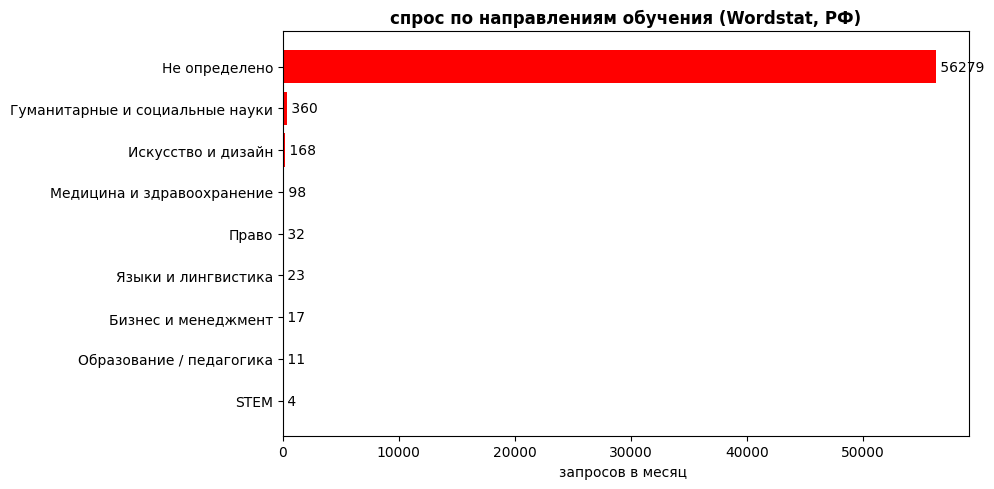

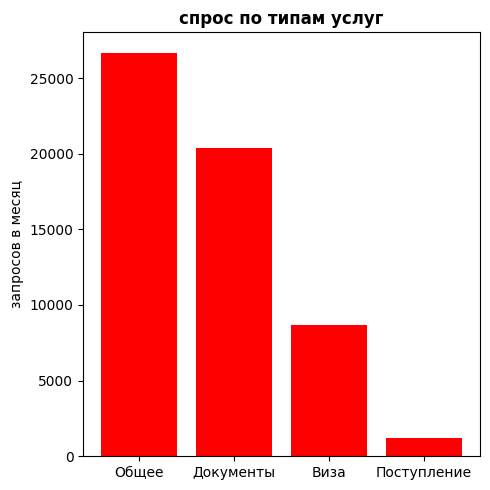

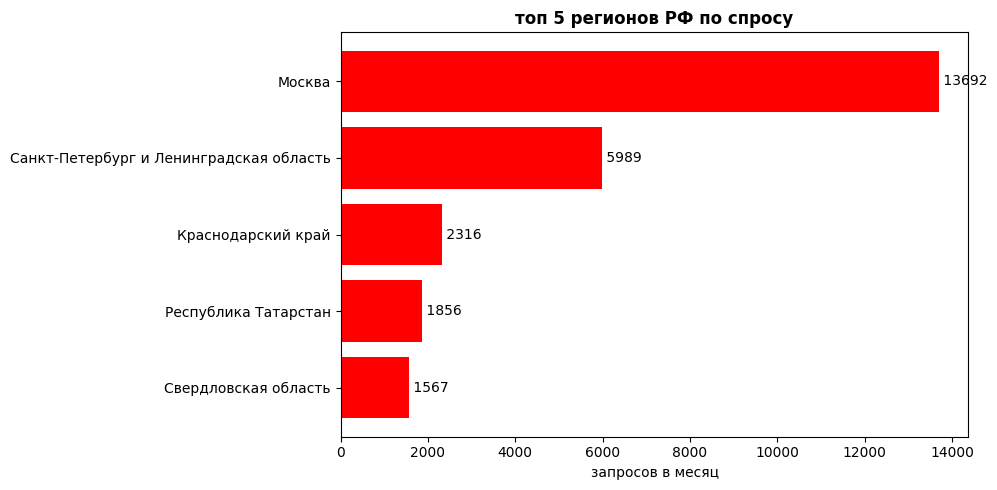

топ 5 регионов:
region
Москва                                     13692
Санкт-Петербург и Ленинградская область     5989
Краснодарский край                          2316
Республика Татарстан                        1856
Свердловская область                        1567


In [6]:
analyze(by_query, by_region)

вот тут я еще дополнила спросом по странам куда хотят поступать

In [7]:
import matplotlib
matplotlib.rcParams["font.family"] = "DejaVu Sans"
import matplotlib.pyplot as plt


def countries_demand(by_query):
    g = by_query.groupby("country")["total_shows"].sum()
    g = g[g.index != "Не указана"]               # фразы без стран не считаю
    return g.sort_values(ascending=False)


def analyze_countries(by_query, save=True):
    g = countries_demand(by_query)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(g.index[::-1], g.values[::-1], color = "red")
    ax.set_xlabel("запросов в месяц ")
    ax.set_title("спрос по странам ", fontweight = "bold")
    for i, v in enumerate(g.values[::-1]):
        ax.text(v, i, f" {int(v)}", va = "center", fontsize = 10)
    plt.tight_layout()
    plt.show()

    print("Спрос по странам")
    print(g.to_string())

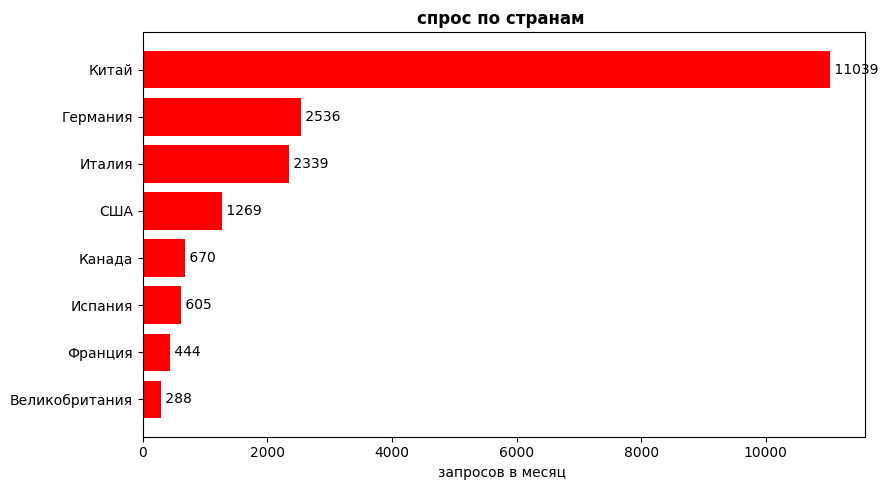

Спрос по странам
country
Китай             11039
Германия           2536
Италия             2339
США                1269
Канада              670
Испания             605
Франция             444
Великобритания      288


In [8]:
analyze_countries(by_query)

In [9]:
by_query.to_csv("wordstat_by_query.csv", index = False)
by_region.to_csv("wordstat_by_region.csv", index = False)